# <a id='toc1_'></a>[Main code for analyzing HAPPEN data](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Main code for analyzing HAPPEN data](#toc1_)    
  - [Intro](#toc1_1_)    
  - [Load data](#toc1_2_)    
    - [Select max of three if all below threshold](#toc1_2_1_)    
    - [Select only repeated measurement that are expected](#toc1_2_2_)    
  - [Calculate percentages below threshold](#toc1_3_)    
  - [Calculate percentage of measurements that were actually done](#toc1_4_)    
  - [Compute standard deviations from repeated measurements](#toc1_5_)    
  - [Calculate expectation values](#toc1_6_)    
    - [x1](#toc1_6_1_)    
    - [x2 and x3](#toc1_6_2_)    
  - [Probability of meas below threshold](#toc1_7_)    
    - [Over full distribution](#toc1_7_1_)    
    - [For specific donor with true Hb](#toc1_7_2_)    
  - [Expected deferrals](#toc1_8_)    
    - [Current deferral rate from data](#toc1_8_1_)    
  - [Plot distributions](#toc1_9_)    
    - [Happen 1-3 Hb measurement with prediction](#toc1_9_1_)    
    - [New donors 2017-2024](#toc1_9_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Intro](#toc0_)
Main code for analyzing data for paper Understanding the impact of conditionally repeated hemoglobin measurements in the Netherlands by Mart Pothast, Katja vd Hurk & Mart Janssen.

First the HAPPEN data is analyzed and the measurement uncertainty and population distribution is determined. Then the Hb distr of first time donors is analyzed.

To run the notebook you need numpy, pandas matplotlib, scipy and numba

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as scistats

from scipy.integrate import quad

#All the magic is imported from here, see there for implementation of pdfs
from cond_distr import *

N_BOOTSTRAPS = 1000

DATA_DIR = '/mnt/c/Users/potha01m/data'

def load_data():
    filename = os.path.join(DATA_DIR, "analysefile_Happen.sav")
    df = pd.read_spss(filename)
    n = len(df)
    df.loc[:, "Geslacht_new"] = 0
    df.loc[df["Geslacht"] == "vrouw", "Geslacht_new"] = 1
    df["sex"] = df["Geslacht_new"]
    df["Hbv"] = df["Hbveneus"]
    df = df.reset_index()
    return df

## <a id='toc1_2_'></a>[Load data](#toc0_)

In [2]:
df = load_data()
print(f"Males = {len(df.loc[df['sex'] == 0])}")
print(f"Females = {len(df.loc[df['sex'] == 1])}")

Males = 1377
Females = 1230


### <a id='toc1_2_1_'></a>[Select max of three if all below threshold](#toc0_)
This is what happens in donation data

In [3]:
#This is the procedure that is normally stored
def procedure(x1, x2, x3, cut):
    #strategy for sequential testing
    return np.where((x1 < cut)&np.isfinite(x2), np.where((x2 < cut)&np.isfinite(x3), np.nanmax([x1, x2, x3], axis=0), x2), x1)

df_m = df.query('sex == 0').copy()
df_f = df.query('sex == 1').copy()
df_m['Hb_max'] = procedure(df_m['Hb201a'], df_m['Hb201b'], df_m['Hb201c'], 8.4)
df_f['Hb_max'] = procedure(df_f['Hb201a'], df_f['Hb201b'], df_f['Hb201c'], 7.8)
df = pd.concat([df_m, df_f])

### <a id='toc1_2_2_'></a>[Select only repeated measurement that are expected](#toc0_)
If prior is below threshold

In [4]:
#Only get those measurements that you expect to get, i.e. remove those that have been repeated but were the measurement before was not below the threshold

def get_correct_repeated_meas(hb201a, hb201b, hb201c, cut):
    hb201a = hb201a.copy()
    hb201b = hb201b.copy()
    hb201c = hb201c.copy()
    hb201b[hb201a >= cut] = np.nan
    hb201c[(hb201a >= cut)|(hb201b >= cut)] = np.nan
    return hb201a, hb201b, hb201c

df_f[['Hb201a_', 'Hb201b_', 'Hb201c_']] = pd.Series(get_correct_repeated_meas(df_f['Hb201a'].values, df_f['Hb201b'].values, df_f['Hb201c'].values, 7.8))
df_m[['Hb201a_', 'Hb201b_', 'Hb201c_']] = pd.Series(get_correct_repeated_meas(df_m['Hb201a'].values, df_m['Hb201b'].values, df_m['Hb201c'].values, 8.4))
df = pd.concat([df_f, df_m])

## <a id='toc1_3_'></a>[Calculate percentages below threshold](#toc0_)
With confidence intervals 

In [5]:
def calc_percentage_below_cut_data(data, cut, N=None):
    if N is None:
        bs = scistats.bootstrap((data,), lambda x: 100 * (x < cut).sum() / len(x))
    else:
        bs = scistats.bootstrap((data,), lambda x: 100 * (x < cut).sum() / N)

    # perc = (bs.bootstrap_distribution).mean()
    if N is None:
        perc = 100 * (data < cut).sum() / len(data)
    else:
        perc = 100 * (data < cut).sum() / N
    return (
        (data < cut).sum(),
        perc,
        bs.confidence_interval[0],
        bs.confidence_interval[1],
    )


def calc_all_percentages(df, cut, use_301=False):
    if use_301:
        hb1 = df["Hb301a"].values
        hb2 = df["Hb301b"].values
        hb3 = df["Hb301c"].values
    else:
        hb1 = df["Hb201a"].values
        hb2 = df["Hb201b"].values
        hb3 = df["Hb201c"].values
    N = np.isfinite(hb1).sum()
    N2 = np.isfinite(hb2).sum()
    N3 = np.isfinite(hb3).sum()
    print(f"{N2} = {N2/N*100:.2f}% are repeated once")
    print(f"{N3} = {N3/N*100:.2f}% are repeated twice")
    n1, p1, p1_low, p1_high = calc_percentage_below_cut_data(
        hb1,
        cut,
        N=N,
    )
    n2, p2, p2_low, p2_high = calc_percentage_below_cut_data(
        hb2[hb1 < cut],
        cut,
        N=N,
    )
    n3, p3, p3_low, p3_high = calc_percentage_below_cut_data(
        hb3[(hb1 < cut) & (hb2 < cut)],
        cut,
        N=N,
    )
    print(f"1st below {cut} = {n1}, {p1:.2f} [{p1_low:.2f}, {p1_high:.2f}]")
    print(f"2nd below {cut} = {n2}, {p2:.2f} [{p2_low:.2f}, {p2_high:.2f}]")
    print(f"3rd below {cut} = {n3}, {p3:.2f} [{p3_low:.2f}, {p3_high:.2f}]")

print("---------------")
print("201")
print("Females")
calc_all_percentages(df.loc[df["sex"] == 1], 7.8)
print("Males")
calc_all_percentages(df.loc[df["sex"] == 0], 8.4)
print("---------------")

---------------
201
Females
142 = 11.54% are repeated once
60 = 4.88% are repeated twice
1st below 7.8 = 141, 11.46 [9.84, 13.33]
2nd below 7.8 = 68, 5.53 [4.63, 6.50]
3rd below 7.8 = 39, 3.17 [2.52, 3.82]
Males
77 = 5.59% are repeated once
33 = 2.40% are repeated twice
1st below 8.4 = 74, 5.37 [4.21, 6.61]
2nd below 8.4 = 29, 2.11 [1.53, 2.76]
3rd below 8.4 = 15, 1.09 [0.73, 1.45]
---------------


## <a id='toc1_4_'></a>[Calculate percentage of measurements that were actually done](#toc0_)
But maybe should not have and vice-versa

In [6]:
def perc_of_meas_done(df, cut, meas='201'):
    print(meas)
    hba = df[f'Hb{meas}a'].values
    hbb = df[f'Hb{meas}b'].values
    hbc = df[f'Hb{meas}c'].values
    ntot = len(hba)
    low_a = hba < cut
    b = np.isfinite(hbb)
    n_low_a = low_a.sum()
    p_meas_b = (b&low_a).sum()/n_low_a
    
    print(f"Percetange of second measurement below cutoff and done: {(b&low_a).sum()/ntot*100:.2f} of total {low_a.sum()}")
    print(f"Percentage of second measurement that should have been done given first is below {cut}: {p_meas_b*100:.2f}% of {n_low_a}")
    print(f"percentage of second measurement w/out first < cut {(b&~low_a).sum()/ntot*100:.2f}")
    print(scistats.kstest(hba[low_a&b], hba[low_a&~b]))

    low_b = hbb < cut
    c = np.isfinite(hbc)
    n_low_b = low_b.sum()
    p_meas_c = (c&low_b).sum()/n_low_b
    print(f"Percetange of third measurement below cutoff and done: {(c&low_b).sum()/ntot*100:.2f} of total {low_b.sum()}")
    print(f"Percentage of third measurement that should have been done given second is below {cut}: {p_meas_c*100:.2f}% of {n_low_b}")
    print(f"percentage of third measurement w/out second < cut {(c&~low_b).sum()/ntot*100:.2f}")
    print(scistats.kstest(hbb[low_b&c], hbb[low_b&~c]))
    
print("Males")
perc_of_meas_done(df.loc[df['sex'] == 0], 8.4)
print("--------")
print("Females")
perc_of_meas_done(df.loc[df['sex'] == 1], 7.8)

Males
201
Percetange of second measurement below cutoff and done: 4.65 of total 74
Percentage of second measurement that should have been done given first is below 8.4: 86.49% of 74
percentage of second measurement w/out first < cut 0.94
KstestResult(statistic=np.float64(0.234375), pvalue=np.float64(0.6482378705299677), statistic_location=np.float64(7.8), statistic_sign=np.int8(1))
Percetange of third measurement below cutoff and done: 1.53 of total 30
Percentage of third measurement that should have been done given second is below 8.4: 70.00% of 30
percentage of third measurement w/out second < cut 0.87
KstestResult(statistic=np.float64(0.20634920634920634), pvalue=np.float64(0.9014445224939979), statistic_location=np.float64(8.1), statistic_sign=np.int8(-1))
--------
Females
201
Percetange of second measurement below cutoff and done: 10.41 of total 141
Percentage of second measurement that should have been done given first is below 7.8: 90.78% of 141
percentage of second measurement 

## <a id='toc1_5_'></a>[Compute standard deviations from repeated measurements](#toc0_)

Ussually from repeated measurments you can estimate the measurement uncertainty from
$$
\sigma_{meas} = \mathrm{SD}(x_1-x_2)/\sqrt{2}
$$
With conditionally repeated measurements there is a correction factor to this given by `correct_std_dev_cond`

This depends slightly on $\sigma_{pop}$. Which is given by
$$
\mathrm{SD}(x_1)^2 = \sigma_{meas}^2 + \sigma_{pop}^2
$$
So iterate a couple of times to get $\sigma_{meas}$ and $\sigma_{pop}$

Male results:
Measurement uncertainty = 0.38, 95%CI [0.319, 0.441]
Std population = 0.56, 95%CI [0.504, 0.611]
Female results:
Measurement uncertainty = 0.37, 95%CI [0.301, 0.454]
Std population = 0.52, 95%CI [0.448, 0.581]


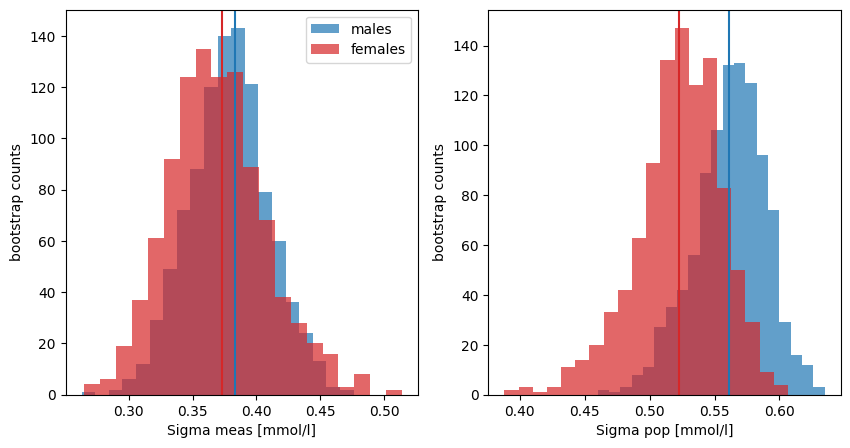

In [7]:
def compute_std_meas_cap(x1, x2, xv, n=10):
    hba_mean = np.mean(x1)
    hba_std = np.std(x1)
    # mask = np.isfinite(x2&x1)
    # std_diff = np.std(x1[mask]-x2[mask])
    std_diff = np.nanstd(x1 - x2) / 2**0.5
    pop_std_min = 0.1
    pop_std = 0.55  # good start estimate
    for _ in range(n):
        std_hc = correct_std_dev_cond(std_diff, pop_std)
        if std_hc > hba_std:
            pop_std = pop_std_min
        else:
            pop_std = (hba_std**2 - std_hc**2) ** 0.5

        if pop_std < pop_std_min:
            pop_std_min = pop_std
    hbv_hba_diff_std = np.nanstd(x1 - xv)
    # independelty we can get sigma venous, but not used here
    sig_v = np.maximum(hbv_hba_diff_std**2 - std_hc**2, 0) ** 0.5
    pop_std_v = (np.var(xv) - sig_v**2) ** 0.5
    return std_hc, pop_std, sig_v, pop_std_v, hba_mean


# bootstrap the whole procedure

# result over all
std_meas_cap_m, std_pop_m, std_meas_v_m, std_pop_v_m, hba_mean_m = compute_std_meas_cap(
    df_m["Hb201a_"], df_m["Hb201b_"], df_m["Hbv"]
)
std_meas_cap_f, std_pop_f, std_meas_v_f, std_pop_v_f, hba_mean_f = compute_std_meas_cap(
    df_f["Hb201a_"], df_f["Hb201b_"], df_f["Hbv"]
)
sig_tot_m = (std_meas_cap_m**2 + std_pop_m**2) ** 0.5
sig_tot_f = (std_meas_cap_f**2 + std_pop_f**2) ** 0.5
rho_m = std_pop_m**2 / sig_tot_m**2
rho_f = std_pop_f**2 / sig_tot_f**2
mu_pop_m = np.mean(df_m["Hb201a"])
mu_pop_f = np.mean(df_f["Hb201a"])

bs_std_meas_cap_m = scistats.bootstrap(
    (df_m["Hb201a_"].values, df_m["Hb201b_"].values, df_m["Hbv"]),
    statistic=compute_std_meas_cap,
    n_resamples=N_BOOTSTRAPS,
    paired=True,
    method="percentile",
)
bs_std_meas_cap_f = scistats.bootstrap(
    (df_f["Hb201a_"].values, df_f["Hb201b_"].values, df_f["Hbv"]),
    statistic=compute_std_meas_cap,
    n_resamples=N_BOOTSTRAPS,
    paired=True,
    method="percentile",
)


def extract_95CI(bs, i):
    low = bs.confidence_interval.low[i]
    high = bs.confidence_interval.high[i]
    return f"[{low:.3f}, {high:.3f}]"

print("Male results:")
print(
    f"Measurement uncertainty = {std_meas_cap_m:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_m, 0)}"
)
print(f"Std population = {std_pop_m:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_m, 1)}")

print("Female results:")
print(
    f"Measurement uncertainty = {std_meas_cap_f:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_f, 0)}"
)
print(f"Std population = {std_pop_f:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_f, 1)}")
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))


ax1.hist(bs_std_meas_cap_m.bootstrap_distribution[0], bins=20, alpha=0.7, label="males")
ax1.hist(
    bs_std_meas_cap_f.bootstrap_distribution[0],
    bins=20,
    alpha=0.7,
    color="C3",
    label="females",
)
ax1.axvline(std_meas_cap_m, color="C0")
ax1.axvline(std_meas_cap_f, color="C3")
ax2.hist(bs_std_meas_cap_m.bootstrap_distribution[1], bins=20, alpha=0.7)
ax2.hist(bs_std_meas_cap_f.bootstrap_distribution[1], bins=20, alpha=0.7, color="C3")
ax2.axvline(std_pop_m, color="C0")
ax2.axvline(std_pop_f, color="C3")
ax1.set(xlabel="Sigma meas [mmol/l]", ylabel="bootstrap counts")
ax2.set(xlabel="Sigma pop [mmol/l]", ylabel="bootstrap counts")
ax1.legend()

## <a id='toc1_6_'></a>[Calculate expectation values](#toc0_)
Expectation value = mean  
also bootstrap these

### <a id='toc1_6_1_'></a>[x1](#toc0_)

In [8]:
bs_mean_x1_m = scistats.bootstrap((df_m['Hb201a'], ), np.mean, n_resamples=N_BOOTSTRAPS)
bs_mean_x1_f = scistats.bootstrap((df_f['Hb201a'], ), np.mean, n_resamples=N_BOOTSTRAPS)
mu_pop_m_low = np.quantile(bs_mean_x1_m.bootstrap_distribution, 0.025)
mu_pop_m_high = np.quantile(bs_mean_x1_m.bootstrap_distribution, 0.975)

mu_pop_f_low = np.quantile(bs_mean_x1_f.bootstrap_distribution, 0.025)
mu_pop_f_high = np.quantile(bs_mean_x1_f.bootstrap_distribution, 0.975)
print(f"Males mean x1 = {mu_pop_m:.3f}, (95% CI {mu_pop_m_low:.3f}, {mu_pop_m_high:.3f})")
print(f"Females mean x1 = {mu_pop_f:.3f}, (95% CI {mu_pop_f_low:.3f}, {mu_pop_f_high:.3f})")

Males mean x1 = 9.389, (95% CI 9.354, 9.424)
Females mean x1 = 8.466, (95% CI 8.432, 8.502)


### <a id='toc1_6_2_'></a>[x2 and x3](#toc0_)

In [9]:
def calc_exp_values_2_3_MC(mu, sig_tot, rho, cut, N=10000):
    # analytical solution for mean of x2, but MC for mean of x3
    # also returns prob of doing 2nd, 3rd meas
    var = sig_tot**2
    var_rho = var * rho
    x123 = np.round(
        np.random.multivariate_normal(
            [mu, mu, mu],
            [[var, var_rho, var_rho], [var_rho, var, var_rho], [var_rho, var_rho, var]],
            size=N,
        ),
        1,
    )
    x1, x2, x3 = x123.T
    mean_x2 = ev_y_func(mu, sig_tot, rho, cut)
    p1 = calc_p1_below_cut(cut, mu, sig_tot)
    p2 = calc_p2_below_cut(cut, mu, sig_tot, rho)
    p3 = calc_p3_below_cut(cut, mu, sig_tot, rho)
    return mean_x2, np.mean(x3[(x1 < cut) & (x2 < cut)]), p1, p2, p3

In [10]:
#Use bootstrap samles on sig_meas and sig_pop from above

output_f = np.zeros((bs_std_meas_cap_f.bootstrap_distribution.shape[1], 5))

for i, xs in enumerate(bs_std_meas_cap_f.bootstrap_distribution.T):
    std_hc, pop_std, _, _, hba_mean = xs
    sig_tot = (pop_std**2 + std_hc**2)**0.5
    rho = pop_std**2/sig_tot**2
    mu_2, mu_3, p1, p2, p3 = calc_exp_values_2_3_MC(hba_mean, sig_tot, rho, 7.75)
    output_f[i] = mu_2, mu_3, p1, p2, p3
    
# f, axs = plt.subplots(1, 5, figsize=(15, 5))
# for i, ax in enumerate(axs):
#     ax.hist(output_f[:, i], bins=20);

mean_x2_f, mean_x3_f, p1_f, p2_f, p3_f = output_f.T
mean_x2_f_val, mean_x3_f_val, _, _, _ = calc_exp_values_2_3_MC(mu_pop_f, sig_tot_f, rho_f, 7.75)
mean_x2_low, mean_x3_low, _, _, _ = np.quantile(output_f, 0.025, axis=0)
mean_x2_high, mean_x3_high, _, _, _ = np.quantile(output_f, 0.975, axis=0)
print("Females")
print(f"Mean x2 = {mean_x2_f_val:.3f} (95% CI {mean_x2_low:.3f}, {mean_x2_high:.3f})")
print(f"Mean x3 = {mean_x3_f_val:.3f} (95% CI {mean_x3_low:.3f}, {mean_x3_high:.3f})")

Females
Mean x2 = 7.778 (95% CI 7.648, 7.955)
Mean x3 = 7.574 (95% CI 7.472, 7.744)


In [11]:
#Use bootstrap samles on sig_meas and sig_pop from above

output_m = np.zeros((bs_std_meas_cap_m.bootstrap_distribution.shape[1], 5))

for i, xs in enumerate(bs_std_meas_cap_m.bootstrap_distribution.T):
    std_hc, pop_std, _, _, hba_mean = xs
    sig_tot = (pop_std**2 + std_hc**2)**0.5
    rho = pop_std**2/sig_tot**2
    mu_2, mu_3, p1, p2, p3 = calc_exp_values_2_3_MC(hba_mean, sig_tot, rho, 8.35)
    output_m[i] = mu_2, mu_3, p1, p2, p3
    
# f, axs = plt.subplots(1, 5, figsize=(15, 5))
# for i, ax in enumerate(axs):
#     ax.hist(output_m[:, i], bins=20);

mean_x2_m, mean_x3_m, p1_m, p2_m, p3_m = output_m.T
mean_x2_m_val, mean_x3_m_val, _, _, _ = calc_exp_values_2_3_MC(mu_pop_m, sig_tot_m, rho_m, 8.35)
mean_x2_low, mean_x3_low, _, _, _ = np.quantile(output_m, 0.025, axis=0)
mean_x2_high, mean_x3_high, _, _, _ = np.quantile(output_m, 0.975, axis=0)
print("Males")
print(f"Mean x2 = {mean_x2_m_val:.3f} (95% CI {mean_x2_low:.3f}, {mean_x2_high:.3f})")
print(f"Mean x3 = {mean_x3_m_val:.3f} (95% CI {mean_x3_low:.3f}, {mean_x3_high:.3f})")

Males
Mean x2 = 8.479 (95% CI 8.346, 8.636)
Mean x3 = 8.210 (95% CI 8.125, 8.387)


## <a id='toc1_7_'></a>[Probability of meas below threshold](#toc0_)
As calculated from best fit params

### <a id='toc1_7_1_'></a>[Over full distribution](#toc0_)

In [12]:
DR = 0.05  # adjust for rounding!

def calc_prob_below_1st(mu, sig, rho, cut):
    return scistats.norm.cdf(cut - DR, mu, sig)
    # return quad(scistats.norm.pdf, -np.inf, cut - DR, args=(mu, sig))[0]


def calc_prob_below_2nd(mu, sig, rho, cut):
    return scistats.multivariate_normal.cdf(
        [cut - DR, cut - DR], [mu, mu], [[sig**2, sig**2 * rho], [sig**2 * rho, sig**2]]
    )
    # return quad(pdf_cond_2nd_meas, -np.inf, cut - DR, args=(mu, sig, rho, cut - DR))[0]


def calc_prob_below_3rd(mu, sig, rho, cut):
    return scistats.multivariate_normal.cdf(
        [cut - DR, cut - DR, cut - DR],
        [mu, mu, mu],
        [
            [sig**2, sig**2 * rho, sig**2 * rho],
            [sig**2 * rho, sig**2, sig**2*rho],
            [sig**2 * rho, sig**2 * rho, sig**2],
        ],
    )
    # return quad(pdf_cond_3rd_meas, -np.inf, cut - DR, args=(mu, sig, rho, cut - DR))[0]


print(
    f"females 1st < cutoff = {calc_prob_below_1st(mu_pop_f, sig_tot_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"females 2nd < cutoff = {calc_prob_below_2nd(mu_pop_f, sig_tot_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"females 3rd < cutoff = {calc_prob_below_3rd(mu_pop_f, sig_tot_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"males 1st < cutoff = {calc_prob_below_1st(mu_pop_m, sig_tot_m, rho_m, 8.35)*100:.1f}%"
)
print(
    f"males 2nd < cutoff = {calc_prob_below_2nd(mu_pop_m, sig_tot_m, rho_m, 8.35)*100:.1f}%"
)
print(
    f"males 3rd < cutoff = {calc_prob_below_3rd(mu_pop_m, sig_tot_m, rho_m, 8.35)*100:.1f}%"
)

females 1st < cutoff = 11.6%
females 2nd < cutoff = 5.3%
females 3rd < cutoff = 3.3%
males 1st < cutoff = 5.4%
males 2nd < cutoff = 2.1%
males 3rd < cutoff = 1.2%


### <a id='toc1_7_2_'></a>[For specific donor with true Hb](#toc0_)

In [13]:
true = 7.7
cut = 7.8
sig_meas = std_meas_cap_f #(std_meas_cap_f + std_meas_cap_f)/2.
# print(sig_meas)
p1 = scistats.norm.sf(cut, true, sig_meas)
p2 = 1-scistats.multivariate_normal.cdf([cut-0.05, cut-0.05], [true, true], [[sig_meas**2, 0], [0, sig_meas**2]])
p3 = 1-scistats.multivariate_normal.cdf([cut-0.05, cut-0.05, cut-0.05], [true, true, true], [[sig_meas**2, 0, 0], [0, sig_meas**2, 0], [0, 0, sig_meas**2]])
print(f"Probability of a true donor with Hb = {true:.2f} to be above the threshold")
print(f"After 1 meas: {p1:.3f}")
print(f"After 2 meas: {p2:.3f}")
print(f"After 3 meas: {p3:.3f}")


Probability of a true donor with Hb = 7.70 to be above the threshold
After 1 meas: 0.394
After 2 meas: 0.694
After 3 meas: 0.831


## <a id='toc1_8_'></a>[Expected deferrals](#toc0_)
If we use only x1

In [14]:
print(f"Female deferral rate = {100*scistats.norm.cdf(7.75, mu_pop_f, sig_tot_f):.2f} %")
print(f"Male deferral rate = {100*scistats.norm.cdf(8.35, mu_pop_m, sig_tot_m):.2f} %")

Female deferral rate = 13.24 %
Male deferral rate = 6.31 %


If we would use the true Hb (if measurement was perfect)

In [15]:
print(f"Female deferral rate = {100*scistats.norm.cdf(7.75, mu_pop_f, std_pop_f):.2f} %")
print(f"Male deferral rate = {100*scistats.norm.cdf(8.35, mu_pop_m, std_pop_m):.2f} %")

Female deferral rate = 8.53 %
Male deferral rate = 3.21 %


### <a id='toc1_8_1_'></a>[Current deferral rate from data](#toc0_)
2024

In [16]:
# This is the same as the .sav file from eProgesa
df_2024 = pd.read_parquet(os.path.join(DATA_DIR, 'Donaties/2024Donatiesplus.parquet'))
df_2024["Hb"] = df_2024["Hb"].mask((df_2024["Hb"] < 2) | (df_2024["Hb"] > 16))
df_2024 = df_2024.query('Donatiesoortcode == "V"')
print(f"Number of donations = {len(df_2024)}, number of unique donors = {df_2024['KeyID'].nunique()}")
df_2024.loc[df_2024['Geslacht'] == "F", 'Hb_deferral'] = df_2024.loc[df_2024['Geslacht'] == "F", 'Hb'] < 7.8
df_2024.loc[df_2024['Geslacht'] == "M", 'Hb_deferral'] = df_2024.loc[df_2024['Geslacht'] == "M", 'Hb'] < 8.4
print("Deferral rate in 2024 (volbloed) [%]: ")
df_2024.groupby('Geslacht')['Hb_deferral'].mean()*100

Number of donations = 402616, number of unique donors = 221351
Deferral rate in 2024 (volbloed) [%]: 


Geslacht
F    4.372053
M    1.641895
Name: Hb_deferral, dtype: object

## <a id='toc1_9_'></a>[Plot distributions](#toc0_)

### <a id='toc1_9_1_'></a>[Happen 1-3 Hb measurement with prediction](#toc0_)

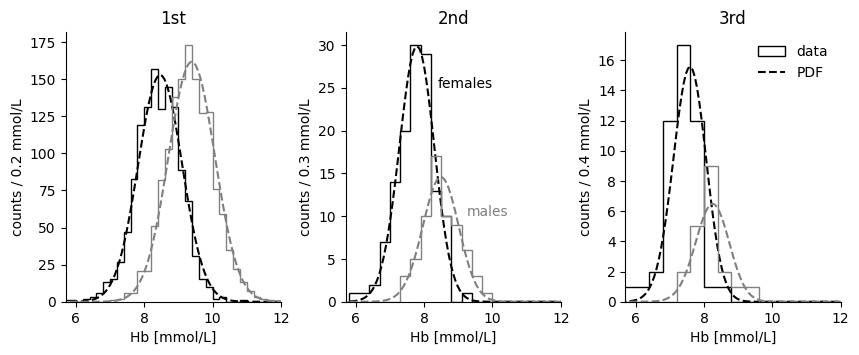

In [17]:
def plot_hist(x, ax, dbins, label=None, **kwargs):
    bins = np.arange(4.0, 14, dbins)
    h, b, pl = ax.hist(x, bins=bins, label=label, **kwargs)
    mb = (b[1:] + b[:-1]) / 2
    mask = h > 0
    return mb, h

df_m = df.query('sex == 0')
df_f = df.query('sex == 1')

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True)

female_color = "k"
female_kwargs = {"histtype": "step", "color": female_color}
plot_hist(df_f["Hb201a_"], ax1, dbins=0.2, **female_kwargs)
plot_hist(df_f["Hb201b_"], ax2, dbins=0.3, **female_kwargs)
plot_hist(df_f["Hb201c_"], ax3, dbins=0.4, label="data", **female_kwargs)
x = np.linspace(5.5, 12, 100)
ax1.plot(
    x,
    df_f["Hb201a_"].notna().sum() * 0.2 * scistats.norm.pdf(x, mu_pop_f, sig_tot_f),
    color=female_color,
    ls="--",
)
ax2.plot(
    x,
    df_f["Hb201b_"].notna().sum()
    * 0.3
    * pdf_cond_2nd_meas(x, mu_pop_f, sig_tot_f, rho_f, 7.75),
    color=female_color,
    ls="--",
)
ax3.plot(
    x,
    df_f["Hb201c_"].notna().sum()
    * 0.4
    * pdf_cond_3rd_meas(x, mu_pop_f, sig_tot_f, rho_f, 7.75),
    color=female_color,
    label="PDF",
    ls="--",
)
male_color = "grey"
male_kwargs = {"histtype": "step", "color": male_color, "density": False, "ls": "-"}
plot_hist(df_m["Hb201a_"], ax1, dbins=0.2, **male_kwargs)
plot_hist(df_m["Hb201b_"], ax2, dbins=0.3, **male_kwargs)
plot_hist(df_m["Hb201c_"], ax3, dbins=0.4, **male_kwargs)
ax1.plot(
    x,
    df_m["Hb201a_"].notna().sum() * 0.2 * scistats.norm.pdf(x, mu_pop_m, sig_tot_m),
    color=male_color,
    ls="--",
)
ax2.plot(
    x,
    df_m["Hb201b_"].notna().sum()
    * 0.3
    * pdf_cond_2nd_meas(x, mu_pop_m, sig_tot_m, rho_m, 8.35),
    color=male_color,
    ls="--",
)
ax3.plot(
    x,
    df_m["Hb201c_"].notna().sum()
    * 0.4
    * pdf_cond_3rd_meas(x, mu_pop_m, sig_tot_m, rho_m, 8.35),
    color=male_color,
    ls="--",
)
ax2.annotate("males", xy=(9.25, 10), color=male_color)
ax2.annotate("females", xy=(8.4, 25), color=female_color)
ax3.legend(frameon=False)
ax1.set(ylabel="counts / 0.2 mmol/L", xlabel="Hb [mmol/L]", title="1st")
ax2.set(ylabel="counts / 0.3 mmol/L", xlabel="Hb [mmol/L]", title="2nd")
ax3.set(ylabel="counts / 0.4 mmol/L", xlabel="Hb [mmol/L]", title="3rd")
for ax in [ax1, ax2, ax3]:
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_xlim([5.7, 12])
    # ax.set_xlim([7.4, 8.])
    # ax.grid()
    
# columns = [('Males', 'observed'), ('Males', 'computed'), ('Females', 'observed'), ('Females', 'computed')]
# t1 = pd.DataFrame(np.zeros((2, 4)), columns=columns, index=['mean', 'count'])
# t1.columns = pd.MultiIndex.from_tuples(t1.columns)
# print(t1)
# t1_ = t1.T.reset_index().T.values[1:, :]
# ax1.table(, colnames=t1bbox=[0, -1, 1, 0.8])
f.subplots_adjust(wspace=0.3)
plt.savefig("Figure1.pdf", bbox_inches="tight")  # , dpi=600)

### <a id='toc1_9_2_'></a>[New donors 2017-2024](#toc0_)

In [18]:
dfs = []
for year in range(2017, 2025):
    #Same as eprogesa .sav files
    df_ = pd.read_parquet(os.path.join(DATA_DIR, f'Donaties/{year}Donatiesplus.parquet'))
    #Only new donors
    df_ = df_.query('Donatiesoortcode == "N"')
    dfs.append(df_)
    
df_don = pd.concat(dfs)
del dfs, df_

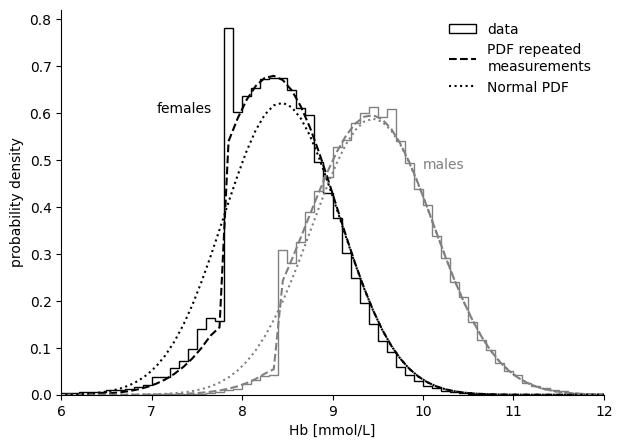

In [19]:

f, ax = plt.subplots(1, figsize=(7, 5))
Hb_f = df_don.query('Geslacht == "F"')['Hb'].values
Hb_m = df_don.query('Geslacht == "M"')['Hb'].values
x_f, h_f = plot_hist(Hb_f, ax=ax, dbins=0.1, color='k', density=True, histtype='step', label='data')
x_m, h_m = plot_hist(Hb_m, ax=ax, dbins=0.1, color='grey', density=True, histtype='step')


pdf_f = pdf_comb(x_f, mu_pop_f-0.03, sig_tot_f, rho_f, 7.8, 0, 0.91, 0.67)
ax.plot(x_f, pdf_f, color='k', ls='--', label='PDF repeated\nmeasurements')
pdf_m = pdf_comb(x_m, mu_pop_m+0.06, sig_tot_m, rho_m, 8.4, 0., 0.86, 0.7)
ax.plot(x_m, pdf_m, color='grey', ls='--')
ax.plot(x_m, scistats.norm.pdf(x_m, mu_pop_m+0.06, sig_tot_m), ':', color='grey')
ax.plot(x_f, scistats.norm.pdf(x_f, mu_pop_f-0.03, sig_tot_f), 'k:', label='Normal PDF')
ax.set(xlim=(6, 12), xlabel='Hb [mmol/L]', ylabel='probability density')
ax.legend(frameon=False)
ax.annotate('males', xy=(10.0, 0.48), color='grey')
ax.annotate('females', xy=(7.05, 0.6), color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("Figure2.pdf", bbox_inches='tight', dpi=700)